In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [125]:
results = pd.read_csv('results/zeroshot.csv')

In [ ]:
results

Index(['model', 'threshold', 'dataset', 'image_id', 'image_file', 'prompt',
       'pred_len', 'gt_len', 'count_accuracy', 'ap_iou_50_95', 'ap_iou_50',
       'ap_iou_75', 'ap_small', 'ap_medium', 'ap_large', 'ar_max_1',
       'ar_max_10', 'ar_max_100', 'ar_small', 'ar_medium', 'ar_large'],
      dtype='object')

In [ ]:
df

In [154]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, r2_score

# Group by dataset, image_file, and prompt
results = results.dropna()
grouped = results.groupby(['model', 'dataset', 'prompt', 'image_file'])
df = results.loc[grouped['count_accuracy'].idxmax()]

# Define function to calculate regression metrics
def calc_regression_metrics(group):
    y_true = group['gt_len']
    y_pred = group['pred_len']

    group_metrics = {
        'rmse': root_mean_squared_error(y_true, y_pred),
        'mape': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'r2': r2_score(y_true, y_pred),
        'error': (y_pred - y_true).mean(),
        'error_var': (y_pred - y_true).var(),
        'error_std': (y_pred - y_true).std(),
        'mean_gt': y_true.mean(),
        'count_accuracy': (y_true == y_pred).mean(),
        'avg_count_accuracy': group['count_accuracy'].mean(),
        'ap_iou_50_95': group['ap_iou_50_95'].mean(),
        'ap_iou_50': group['ap_iou_50'].mean(),
        'ap_iou_75': group['ap_iou_75'].mean(),
        'ap_small': group['ap_small'].mean(),
        'ap_medium': group['ap_medium'].mean(),
        'ap_large': group['ap_large'].mean(),
        'ar_max_1': group['ar_max_1'].mean(),
        'ar_max_10': group['ar_max_10'].mean(),
        'ar_max_100': group['ar_max_100'].mean(),
        'ar_small': group['ar_small'].mean(),
        'ar_medium': group['ar_medium'].mean(),
        'ar_large': group['ar_large'].mean()
    }
    
    return pd.Series(group_metrics)

# Calculate metrics by dataset and prompt
metrics_summary = results.groupby(['model','dataset', 'prompt']).apply(calc_regression_metrics).reset_index()

/tmp/ipykernel_1057406/1582762829.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_summary = results.groupby(['model','dataset', 'prompt']).apply(calc_regression_metrics).reset_index()


In [ ]:
metrics_summary

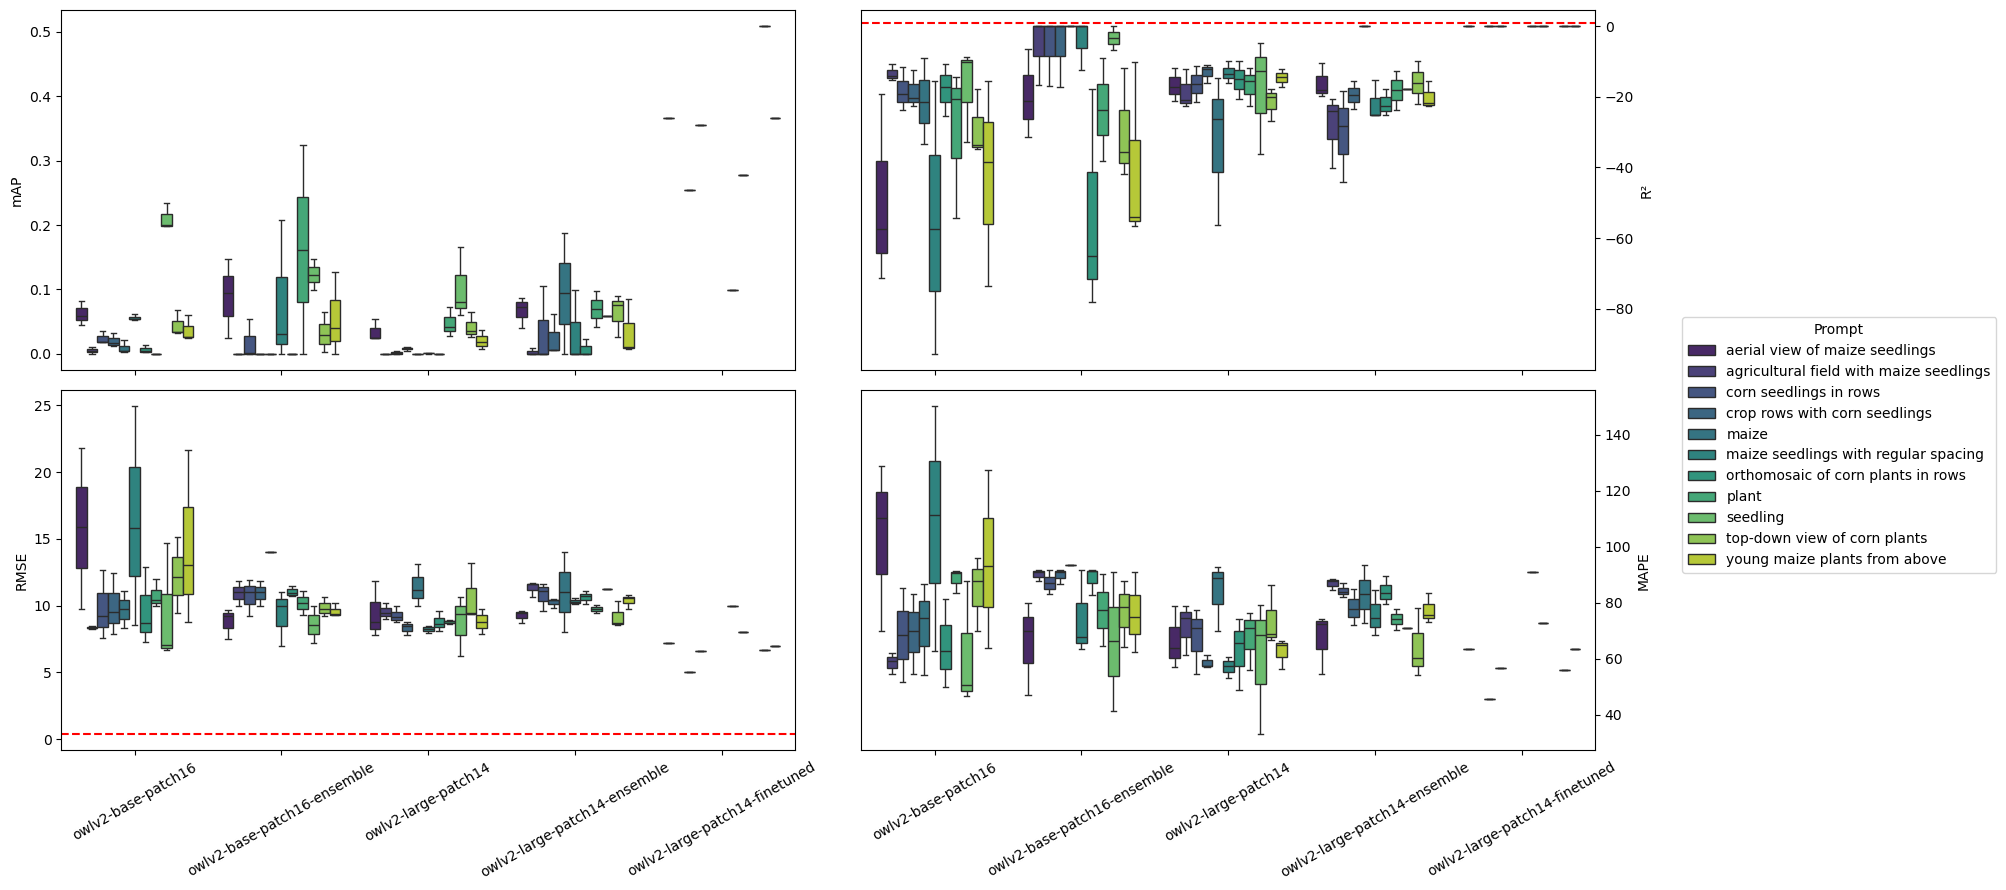

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if the required columns are present in the DataFrame
required_columns = ['model', 'prompt', 'ap_iou_50', 'r2', 'rmse', 'mape']
missing_columns = [col for col in required_columns if col not in metrics_summary.columns]

if missing_columns:
    raise ValueError(f"The following required columns are missing from the DataFrame: {missing_columns}")

# Create figure with 2x2 subplots, sharing the x-axis
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()  # Flatten to make indexing easier

# Define metrics to plot
metrics = ['ap_iou_50', 'r2', 'rmse', 'mape']
ylabels = ['mAP', 'R²', 'RMSE', 'MAPE']

# Create boxplots for each metric
for i, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    # Create the boxplot in the respective subplot
    sns.boxplot(data=metrics_summary, x='model', y=metric, hue='prompt', 
                palette='viridis', ax=axes[i], showfliers=False)
    
    # Set labels for each subplot
    axes[i].set_ylabel(ylabel)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')  # Set x-axis label to an empty string
    
    # Move y-axis ticks and labels to the right for subplots in the second column
    if i % 2 == 1:
        axes[i].yaxis.set_label_position("right")
        axes[i].yaxis.tick_right()
    
    # Add red lines at specific y-values for r2 and rmse subplots
    if metric == 'r2':
        axes[i].axhline(y=0.85, color='red', linestyle='--')
    elif metric == 'rmse':
        axes[i].axhline(y=0.39, color='red', linestyle='--')
    
    # Remove the legend from each subplot
    axes[i].get_legend().remove()

# Get the handles and labels from the last plot
handles, labels = axes[-1].get_legend_handles_labels()

# Create a single legend outside the subplots
fig.legend(handles, labels, title='Prompt', bbox_to_anchor=(1.05, 0.5), 
           loc='center left', frameon=True)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=1)  # Make room for the legend

# Show the plot
# plt.show()

plt.savefig('MDPI_template/Plots/zeroshot.pdf', format='pdf', bbox_inches='tight')

In [ ]:
metrics_summary

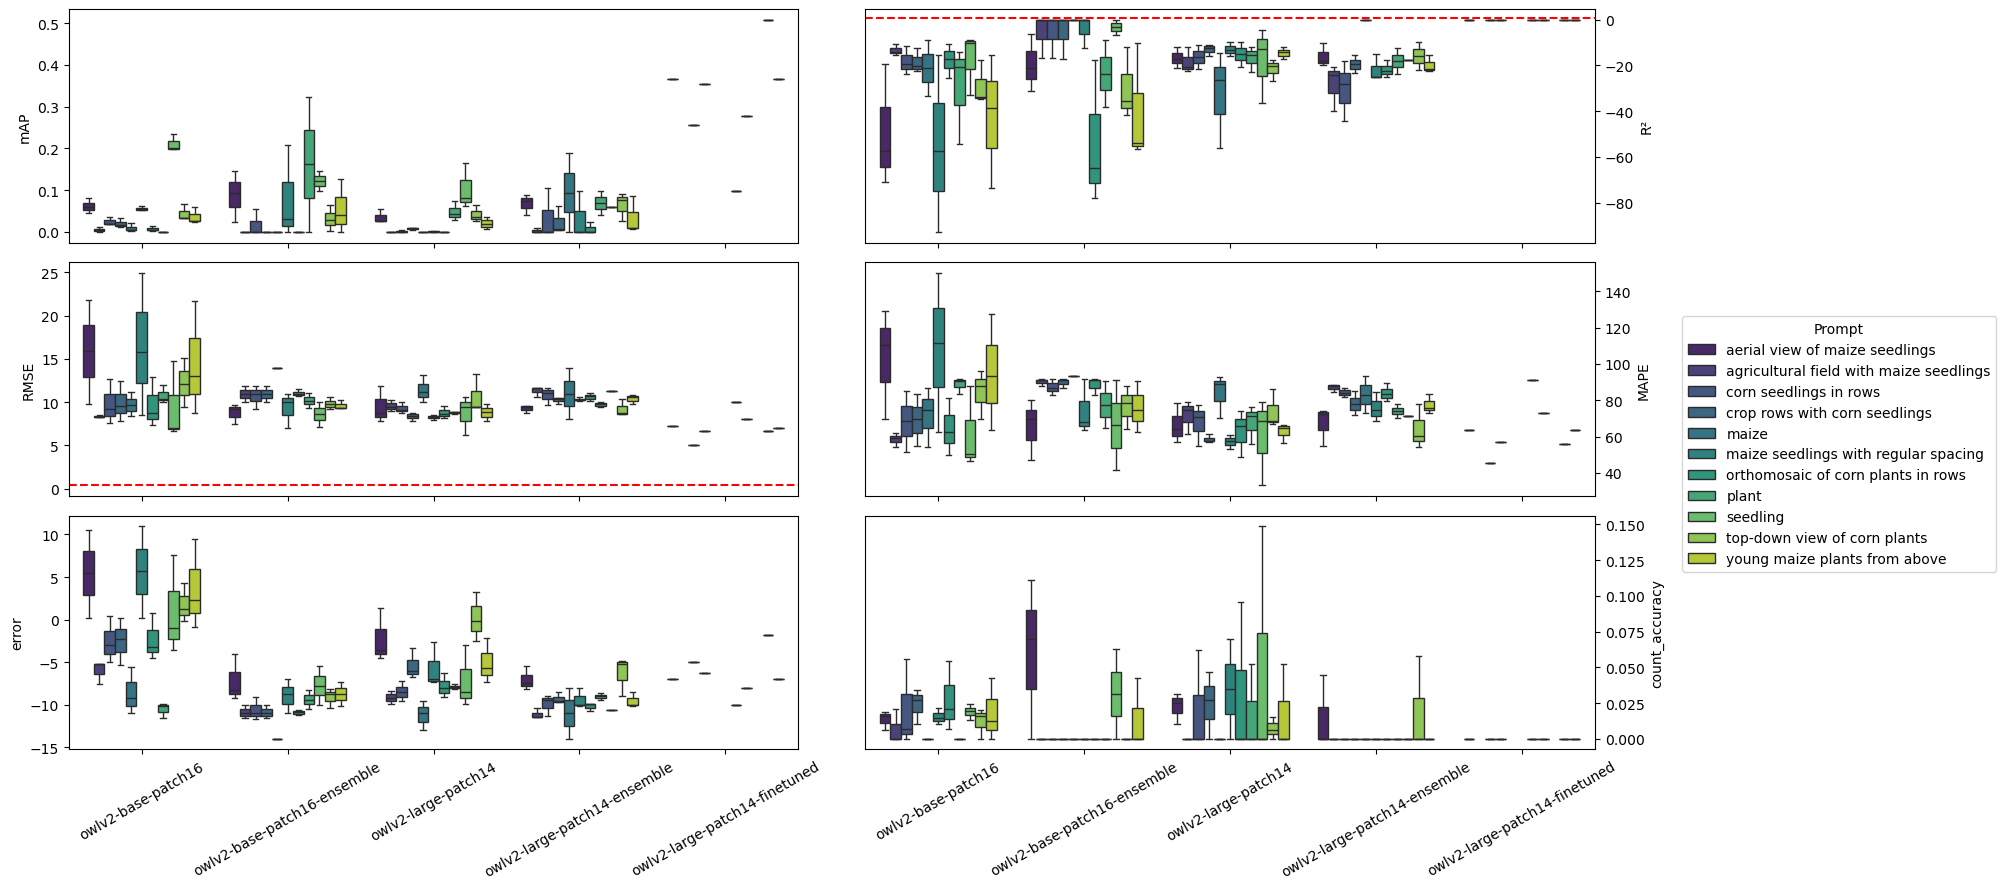

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if the required columns are present in the DataFrame
required_columns = ['model', 'prompt', 'ap_iou_50', 'r2', 'rmse', 'mape', 'error', 'count_accuracy']
missing_columns = [col for col in required_columns if col not in metrics_summary.columns]

if missing_columns:
    raise ValueError(f"The following required columns are missing from the DataFrame: {missing_columns}")

# Create figure with 2x2 subplots, sharing the x-axis
fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()  # Flatten to make indexing easier

# Define metrics to plot
metrics = ['ap_iou_50', 'r2', 'rmse', 'mape', 'error', 'count_accuracy']
ylabels = ['mAP', 'R²', 'RMSE', 'MAPE', 'error', 'count_accuracy']

# Create boxplots for each metric
for i, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    # Create the boxplot in the respective subplot
    sns.boxplot(data=metrics_summary, x='model', y=metric, hue='prompt', 
                palette='viridis', ax=axes[i], showfliers=False)
    
    # Set labels for each subplot
    axes[i].set_ylabel(ylabel)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')  # Set x-axis label to an empty string
    
    # Move y-axis ticks and labels to the right for subplots in the second column
    if i % 2 == 1:
        axes[i].yaxis.set_label_position("right")
        axes[i].yaxis.tick_right()
    
    # Add red lines at specific y-values for r2 and rmse subplots
    if metric == 'r2':
        axes[i].axhline(y=0.85, color='red', linestyle='--')
    elif metric == 'rmse':
        axes[i].axhline(y=0.39, color='red', linestyle='--')
    
    # Remove the legend from each subplot
    axes[i].get_legend().remove()

# Get the handles and labels from the last plot
handles, labels = axes[-1].get_legend_handles_labels()

# Create a single legend outside the subplots
fig.legend(handles, labels, title='Prompt', bbox_to_anchor=(1.05, 0.5), 
           loc='center left', frameon=True)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=1)  # Make room for the legend

# Show the plot
plt.show()

# plt.savefig('MDPI_template/Plots/zeroshot.pdf', format='pdf', bbox_inches='tight')

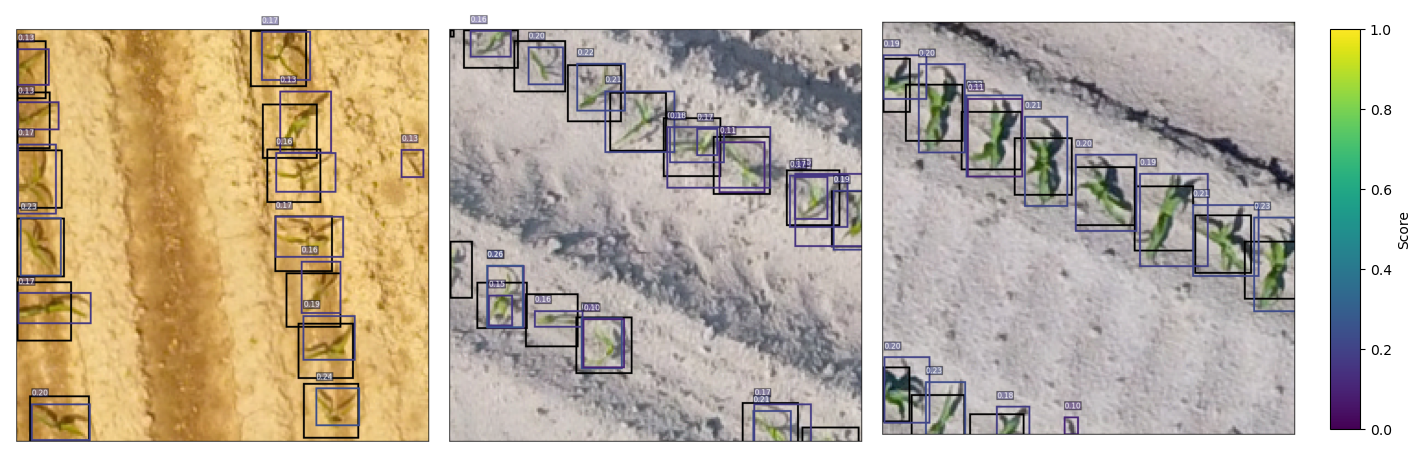

In [102]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from PIL import Image

# Assuming you have already created your subplots and plotted your data
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

image1 = '/mnt/e/PhD/Paper2/plots/OWLv2/seedling_SAGIT22_C_4175_2022_05_27-68-45.tif_owlv2-base-patch16-ensemble.png'
image2 = '/mnt/e/PhD/Paper2/plots/OWLv2/seedling_SAGIT22_C_4178_2022_04_29-63-31.tif_owlv2-base-patch16.png'
image3 = '/mnt/e/PhD/Paper2/plots/OWLv2/seedling_SAGIT22_C_4178_2022_05_10-80-53.tif_owlv2-base-patch16.png'

# Load the images
image1 = Image.open(image1)
image2 = Image.open(image2)
image3 = Image.open(image3)

# Plot your data
axs[0].imshow(image1)
axs[0].axis('off')  # Hide the axes
axs[1].imshow(image2)
axs[1].axis('off')  # Hide the axes
axs[2].imshow(image3)
axs[2].axis('off')  # Hide the axes

# Create a ScalarMappable for the colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)  # Adjust vmin and vmax as needed
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm)
sm.set_array([])

# Adjust subplot parameters to minimize white space
plt.subplots_adjust(left=0.01, right=0.87, bottom=0.01, top=0.99, wspace=0.02)

# Add colorbar to the right of the subplots
cbar_ax = fig.add_axes([0.89, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Score')

plt.savefig('MDPI_template/Plots/zeroshot_images.pdf', format='pdf', bbox_inches='tight')

In [ ]:
df

Index(['model', 'threshold', 'dataset', 'image_id', 'image_file', 'prompt',
       'pred_len', 'gt_len', 'count_accuracy', 'ap_iou_50_95', 'ap_iou_50',
       'ap_iou_75', 'ap_small', 'ap_medium', 'ap_large', 'ar_max_1',
       'ar_max_10', 'ar_max_100', 'ar_small', 'ar_medium', 'ar_large'],
      dtype='object')

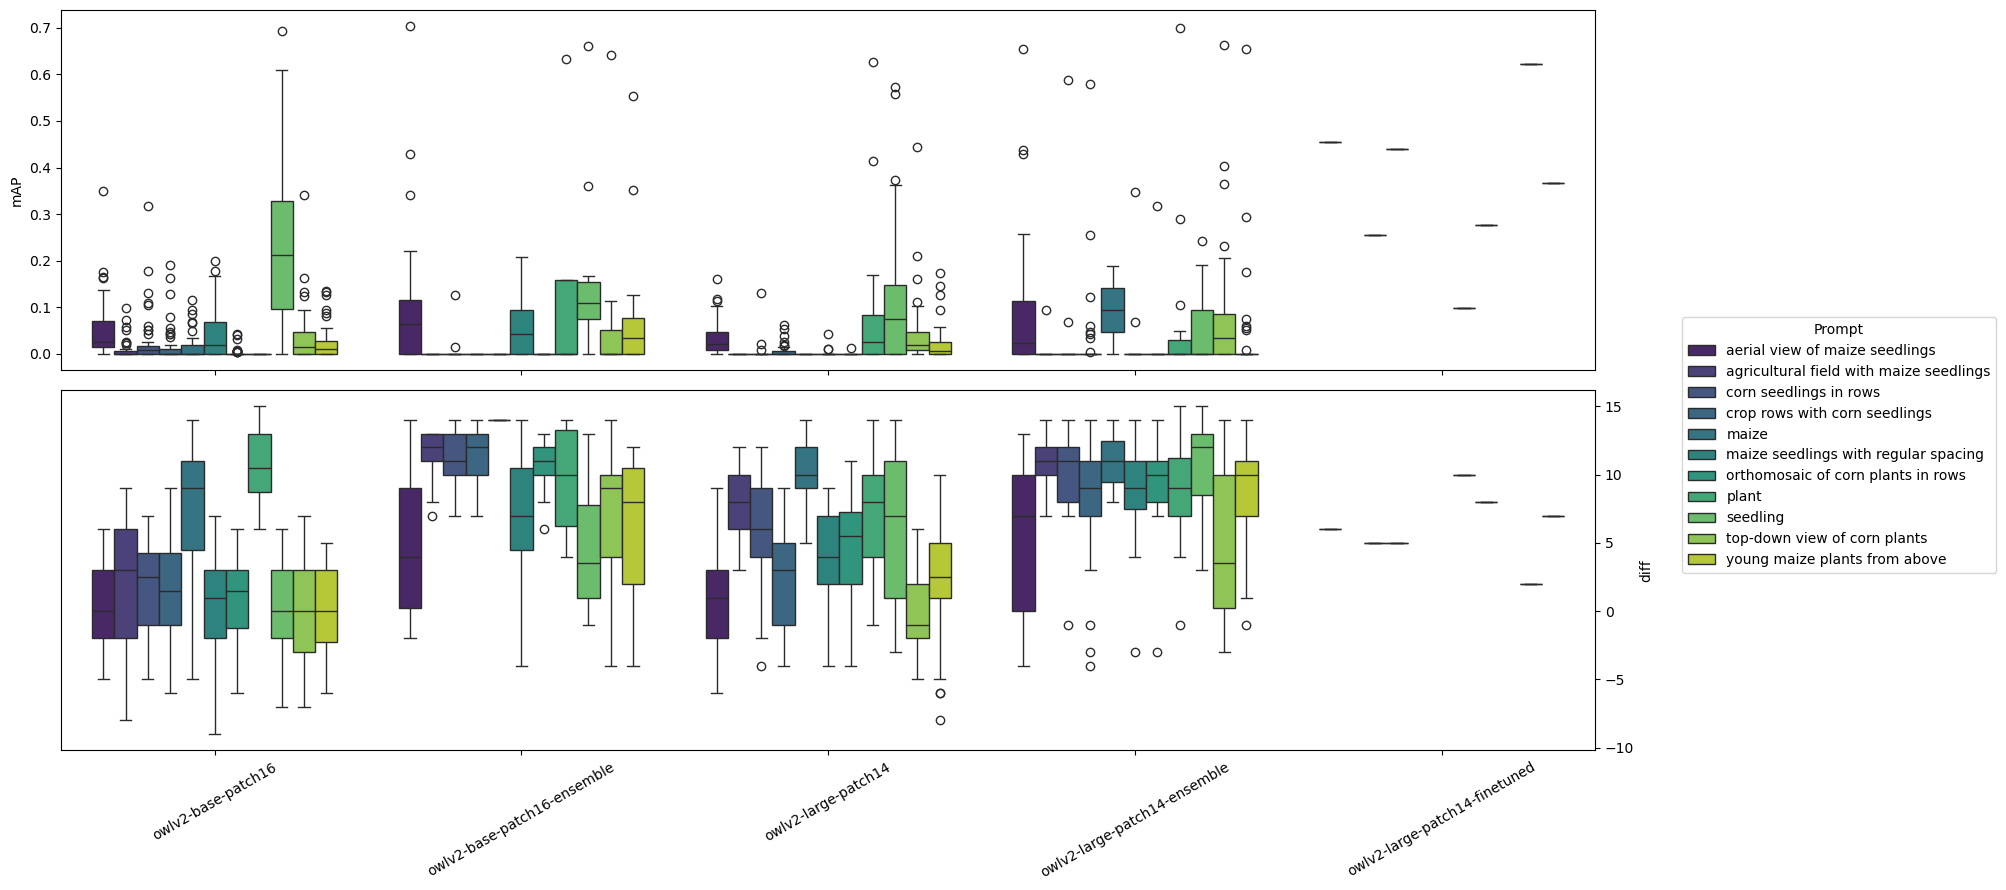

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

df_ = df.copy()

df_['diff'] = df_['gt_len'] - df_['pred_len']

# Check if the required columns are present in the DataFrame
required_columns = ['model', 'prompt', 'ap_iou_50', 'diff']
missing_columns = [col for col in required_columns if col not in df_.columns]

if missing_columns:
    raise ValueError(f"The following required columns are missing from the DataFrame: {missing_columns}")

# Create figure with 2x1 subplots, sharing the x-axis
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
axes = axes.flatten()  # Flatten to make indexing easier

# Define metrics to plot
metrics = ['ap_iou_50', 'diff']
ylabels = ['mAP', 'diff']

# Create boxplots for each metric
for i, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    # Create the boxplot in the respective subplot
    sns.boxplot(data=df_, x='model', y=metric, hue='prompt', 
                palette='viridis', ax=axes[i], showfliers=True)
    
    # Set labels for each subplot
    axes[i].set_ylabel(ylabel)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')  # Set x-axis label to an empty string
    
    # Move y-axis ticks and labels to the right for subplots in the second column
    if i % 2 == 1:
        axes[i].yaxis.set_label_position("right")
        axes[i].yaxis.tick_right()
    
    # Add red lines at specific y-values for r2 and rmse subplots
    if metric == 'r2':
        axes[i].axhline(y=0.85, color='red', linestyle='--')
    elif metric == 'rmse':
        axes[i].axhline(y=0.39, color='red', linestyle='--')
    
    # Remove the legend from each subplot
    axes[i].get_legend().remove()

# Get the handles and labels from the last plot
handles, labels = axes[-1].get_legend_handles_labels()

# Create a single legend outside the subplots
fig.legend(handles, labels, title='Prompt', bbox_to_anchor=(1.05, 0.5), 
           loc='center left', frameon=True)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=1)  # Make room for the legend

# Show the plot
plt.show()

# plt.savefig('MDPI_template/Plots/zeroshot.pdf', format='pdf', bbox_inches='tight')

In [115]:
from os.path import join
import shutil
from os import makedirs
folder = 'MDPI_template/Plots/OWLv2_Best'
makedirs(folder, exist_ok=True)
for row in df.iterrows():
    path = join("/mnt/e/PhD/Paper2/plots/OWLv2", f"{row[1]['prompt']}_{row[1]['image_file']}_{row[1]['model']}.png")
    shutil.copy(path, folder)